In [1]:
import datetime
import sys, os, logging
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline 
from pathlib import Path

logging.basicConfig(level=logging.INFO, format="%(asctime)s %(levelname)s %(message)s")

# Project root
PROJECT_ROOT = Path(os.path.abspath("../../.."))
sys.path.insert(0, str(PROJECT_ROOT))

from inference.prefilter_model.utils import list_h5_parts, load_model, load_mc_test_parts, \
    load_exp_parts, predict_scores, plot_event_3d

%load_ext autoreload
%autoreload 2

In [2]:
# ── Paths ──

#MODEL_NAME = "da_prefilter_numu_260410_1119_Qclip_softlabels_PlateauLR_lambda0.3_MC2M_dmodel128_zflipBothMCExp_FocalLoss" #da_prefilter_numu_260401_0735_hardlabels_lambda0.3_zflipBothMCExp
MODEL_NAME = "da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss"
#CHECKPOINT_PATH = "experiments/numu/da_prefilter_numu_260327_0127/best_da_model.pth"
#CHECKPOINT_PATH = "experiments/numu/da_numu_251123_small_moderatelambdmidddnoreg_aug_newlr/best_da_model.pth"
CHECKPOINT_PATH = f"experiments/numu/{MODEL_NAME}/best_da_model.pth"
TRAIN_PARTS_JSON = "/home/albert/Baikal2025/data_manager/datasets/baikal_mc2020_prefilter/prefilter_h5_parts.json"
MC_H5_PATH = "/home/albert/Baikal2025/data_manager/data/h5datasets/baikal_mc_merged.h5"

# ── Figures output directory ──
TIMESTAMP_STR = datetime.datetime.now().strftime("%y%m%d_%H%M%S")
FIGURES_DIR = PROJECT_ROOT / f"experiments/numu/{MODEL_NAME}/figures_suppr_recall_{TIMESTAMP_STR}"
FIGURES_DIR.mkdir(parents=True, exist_ok=True)


def save_figure(fig, filename: str, rewrite=True) -> None:
    """Save figure to FIGURES_DIR; raise FileExistsError if already present."""
    fig_path = FIGURES_DIR / filename
    if not rewrite and fig_path.exists():
        raise FileExistsError(f"Figure already exists: {fig_path}")
    fig.savefig(fig_path, dpi=160, bbox_inches="tight")
    print(f"Saved: {fig_path}")

# ── MC test parts to load (from complement of training parts) ──
N_PARTS_PER_PARTICLE = {
    "muatm": 100,
    "nue2": 50,
    "nuatm": 50,
}

# ── Inference settings ──
DEVICE = "cuda:2"
BATCH_SIZE = 1024
MAX_HITS = 500
SEED = 42

In [3]:
# Load model and make preds

model, norm_config, train_config = load_model(
    str(PROJECT_ROOT / CHECKPOINT_PATH), device=DEVICE
)
print(f"Normalization: means={norm_config['means']}, stds={norm_config['stds']}")
print(f"Model amp_clip: {model.amp_clip:.4f} (normalized) "
      f"= Q≈{model.amp_clip * norm_config['stds'][0] + norm_config['means'][0]:.1f} PE")
# MC test set (complement of training parts)
df_mc = load_mc_test_parts(
    h5_path=MC_H5_PATH,
    train_parts_json=TRAIN_PARTS_JSON,
    n_parts_per_particle=N_PARTS_PER_PARTICLE,
    seed=SEED,
)
print(f"MC test: {len(df_mc):,} events")
print(df_mc["particle_type"].value_counts())

2026-05-08 11:00:02,660 INFO Created AttentionFeatureExtractor: 5→128, 4 layers, 4 heads, pooling=cls
2026-05-08 11:00:02,662 INFO Created BinaryClassifier: 128→[32, 16]→1, dropout=0.0, batch_norm=False
2026-05-08 11:00:02,663 INFO Created StandardNeutrinoModel with 404161 parameters
2026-05-08 11:00:02,666 INFO amp_clip: Q=100 PE → normalized=1.6333 (mean=2.0, std=60.0)
2026-05-08 11:00:02,763 INFO Loaded model from epoch 39 (best_metric=0.9982)
2026-05-08 11:00:05,340 INFO Loading 100 test parts for muatm_2020 (complement of 432 training parts)


Normalization: means=[2.0, 0.0, 0.0, 0.0, 0.0], stds=[60.0, 1370.0, 40.0, 40.0, 150.0]
Model amp_clip: 1.6333 (normalized) = Q≈100.0 PE


MC muatm:   0%|          | 0/100 [00:00<?, ?part/s]

2026-05-08 11:00:49,233 INFO Loading 50 test parts for nue2_2020 (complement of 333 training parts)


MC nue2:   0%|          | 0/50 [00:00<?, ?part/s]

2026-05-08 11:01:11,314 INFO Loading 50 test parts for nuatm_2020 (complement of 187 training parts)


MC nuatm:   0%|          | 0/50 [00:00<?, ?part/s]

2026-05-08 11:01:58,312 INFO MC test set: 5,590,751 events loaded


MC test: 5,590,751 events
particle_type
muatm_2020    2887924
nuatm_2020    1729889
nue2_2020      972938
Name: count, dtype: int64


Text(0.5, 23.52222222222222, 'Energy')

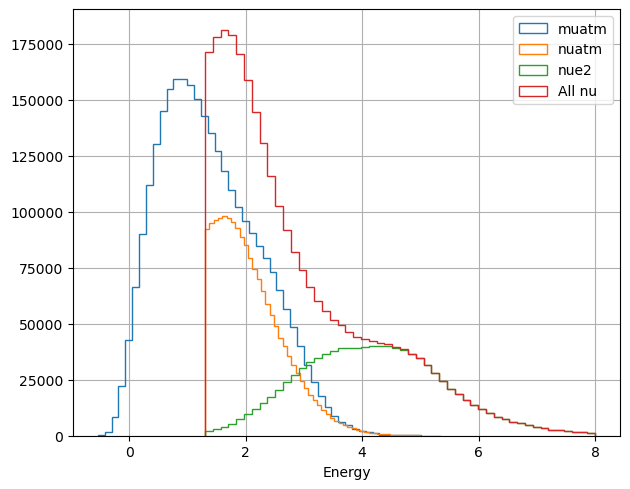

In [5]:
is_mu = df_mc['particle_type'].str.startswith('muatm')
is_nuatm = df_mc['particle_type'].str.startswith('nuatm')
is_nue2 = df_mc['particle_type'].str.startswith('nue2')
hist_kwargs = dict(bins=50, histtype='step', density=False)
values = df_mc['energy'].apply(np.log10)
#values = df_mc['theta']

values[is_mu].hist(label='muatm', **hist_kwargs)
values[is_nuatm].hist(label='nuatm', **hist_kwargs)
values[is_nue2].hist(label='nue2', **hist_kwargs)
values[is_nue2 | is_nuatm].hist(label='All nu', **hist_kwargs)
plt.legend()
plt.tight_layout()
plt.xlabel('Energy')

In [ ]:
df_mc["score"] = predict_scores(
    model, df_mc["features"].tolist(), norm_config,
    batch_size=BATCH_SIZE, max_hits=MAX_HITS, device=DEVICE,
)
print(f"MC scores: mean={df_mc['score'].mean():.4f}, median={df_mc['score'].median():.4f}")

## Plots

In [ ]:
RC_PARAMS = {
    "font.size": 16,
    "axes.labelsize": 20,
    "xtick.labelsize": 18,
    "ytick.labelsize": 18,
    "legend.fontsize": 14,
}

/tmp/ipykernel_2721467/3671429382.py:81: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), 10, SUPP_CLIP)
/tmp/ipykernel_2721467/3671429382.py:55: RuntimeWarning: divide by zero encountered in divide
  inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)


Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss/figures_suppr_recall_260503_151200/DAPrefilterSuppVsE_8_2.png


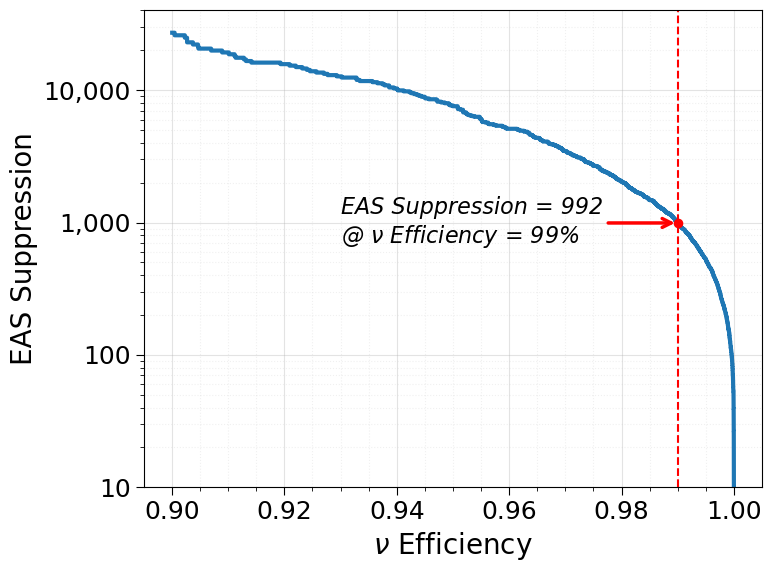

In [ ]:
import matplotlib.ticker as ticker
from sklearn.metrics import roc_curve

# ── Config ──
REF_H          = 8
REF_S          = 2
SUPP_CLIP      = 1e6
REF_TPR_TARGET = 0.99
CUT_LABEL      = f"Signal hits≥{REF_H}, Signal strings≥{REF_S}"

# ── Precompute arrays ──
df_mc["is_neutrino"] = df_mc["particle_type"].str.startswith("nu")
SCORES     = df_mc["score"].values
SIG_HITS   = df_mc["n_signal_hits"].values
SIG_S      = df_mc["n_signal_strings"].values
IS_NU      = df_mc["is_neutrino"].values
IS_MU      = ~IS_NU
ptypes_arr = df_mc["particle_type"].values

pos_nue2  = (ptypes_arr == "nue2_2020")
pos_nuatm = (ptypes_arr == "nuatm_2020")


def make_quality_mask(h: int, s: int) -> np.ndarray:
    if h == 0:
        return np.ones(len(df_mc), dtype=bool)
    return (SIG_HITS >= h) & (SIG_S >= s)


def balanced_nuatm_nue2_subsample(pos_nuatm, pos_nue2, quality: np.ndarray,
                                   seed: int = 42) -> np.ndarray:
    """Subsample nuatm and nue2 to equal counts after quality cut."""
    rng = np.random.default_rng(seed)
    idx_nuatm = np.where(pos_nuatm & quality)[0]
    idx_nue2  = np.where(pos_nue2  & quality)[0]
    n = min(len(idx_nuatm), len(idx_nue2))
    sel_nuatm = rng.choice(idx_nuatm, size=n, replace=False)
    sel_nue2  = rng.choice(idx_nue2,  size=n, replace=False)
    mask = np.zeros(len(ptypes_arr), dtype=bool)
    mask[sel_nuatm] = True
    mask[sel_nue2]  = True
    return mask


def get_ref_point(pos_mask: np.ndarray):
    """Return (tpr, suppression, threshold) at TPR ~ REF_TPR_TARGET."""
    quality = make_quality_mask(REF_H, REF_S)
    keep    = (pos_mask & quality) | (IS_MU & quality)
    y_true  = pos_mask[keep].astype(int)
    y_score = SCORES[keep]
    fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
    thr_arr = thr_arr[1:][::-1]
    tpr_arr = tpr_arr[1:][::-1]
    fpr_arr = fpr_arr[1:][::-1]
    inv_fpr = np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan)
    idx = min(np.searchsorted(-tpr_arr, -REF_TPR_TARGET), len(thr_arr) - 1)
    return float(tpr_arr[idx]), float(inv_fpr[idx]), float(thr_arr[idx])


# ── Build sample ──
quality         = make_quality_mask(REF_H, REF_S)
pos_nu_balanced = balanced_nuatm_nue2_subsample(pos_nuatm, pos_nue2, quality)
keep            = (IS_NU & pos_nu_balanced & quality) | (IS_MU & quality)

y_true  = (IS_NU & pos_nu_balanced)[keep].astype(int)
y_score = SCORES[keep]

# Event counts after cuts (for title)
n_mu_cut    = int(IS_MU[keep].sum())
n_nuatm_cut = int((pos_nuatm & pos_nu_balanced)[keep].sum())
n_nue2_cut  = int((pos_nue2  & pos_nu_balanced)[keep].sum())

N_bg  = n_mu_cut
N_sig = n_nuatm_cut + n_nue2_cut

# ── ROC ──
fpr_arr, tpr_arr, thr_arr = roc_curve(y_true, y_score)
thr_arr = thr_arr[1:][::-1]
tpr_arr = tpr_arr[1:][::-1]
fpr_arr = fpr_arr[1:][::-1]
inv_fpr = np.clip(np.where(fpr_arr > 0, 1.0 / fpr_arr, np.nan), 10, SUPP_CLIP)
clip    = (thr_arr >= 0) & (thr_arr <= 1) & (tpr_arr >= 0.9)

# # ── Uncertainty bands ──
# fpr_std = np.sqrt(np.clip(fpr_arr * (1 - fpr_arr), 0, None) / N_bg)
# supp_lo = np.clip(1.0 / np.clip(fpr_arr + fpr_std, 1e-12, None), None, SUPP_CLIP)
# supp_hi = np.clip(1.0 / np.clip(fpr_arr - fpr_std, 1e-12, None), None, SUPP_CLIP)
# tpr_std = np.sqrt(np.clip(tpr_arr * (1 - tpr_arr), 0, None) / N_sig)

# ── Reference point ──
ref_tpr, ref_supp, ref_thr = get_ref_point(IS_NU & pos_nu_balanced)

# ── Plot ──
with plt.rc_context(RC_PARAMS):
    fig, ax = plt.subplots(figsize=(8, 6))
    c = plt.rcParams["axes.prop_cycle"].by_key()["color"][0]

    # ax.fill_between(tpr_arr[clip], supp_lo[clip], supp_hi[clip],
    #                 color=c, alpha=0.2, label=r"${\pm}1\sigma$")
    # ax.errorbar(tpr_arr[clip][::50], inv_fpr[clip][::50],
    #             xerr=tpr_std[clip][::50],
    #             fmt="none", color=c, alpha=0.4, capsize=2, lw=0.8)
    ax.plot(tpr_arr[clip], inv_fpr[clip], color=c,
            lw=3, 
            label=CUT_LABEL)

    ax.axvline(REF_TPR_TARGET, color="red", ls="--", #lw=1.2,
            label=fr"$\nu$ Efficiency = {int(REF_TPR_TARGET*100)}%")
    ax.scatter([ref_tpr], [ref_supp], color="red", zorder=5, s=35)
    ax.annotate(
        f"EAS Suppression = {ref_supp:.0f}\n"
        fr"@ $\nu$ Efficiency = {int(REF_TPR_TARGET*100)}%"
        #fr"@ $\xi$ = {ref_thr:.3f}"
        ,
        xy=(ref_tpr, ref_supp),
        xytext=(ref_tpr - 0.06, ref_supp),
        #fontsize=10,
        color="black", fontstyle="italic",
        arrowprops=dict(arrowstyle="->", color="red", lw=2.5), va="center",
    )

    ax.set_yscale("log")
    ax.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax.set_xlabel(r"$\nu$ Efficiency")
    ax.set_ylabel(r"EAS Suppression")
    # ax.set_title(
    #     f"Suppression vs Efficiency  [{CUT_LABEL}]\n"
    #     fr"EAS: {n_mu_cut:,} | $\nu_{{atm}}$: {n_nuatm_cut:,} | $\nu_{{astro}}$: {n_nue2_cut:,}",
    #     fontsize=10,
    # )
    #ax.legend()
    ax.minorticks_on()
    #ax.grid(True, which="both", ls=":", alpha=0.4)
    ax.grid(True, which="major", alpha=0.35)
    ax.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax.tick_params(which="major", length=6)
    ax.tick_params(which="minor", length=3)

    fig.tight_layout()
    save_figure(fig, f"DAPrefilterSuppVsE_{REF_H}_{REF_S}.png")
    # plt.xticks(np.arange(0.9,1.01,0.01).round(2))
    plt.ylim(bottom=10)
    plt.show()


Saved: /home/albert/Baikal2025/experiments/numu/da_prefilter_numu_260429_0155_Qclip_softlabels_PlateauLR_lambda0.05_MC2M_dmodel128_zflipBothMCExp_SoftFocalLoss/figures_suppr_recall_260503_151200/DAPrefilterSuppEffVsEnergy_8_2.png


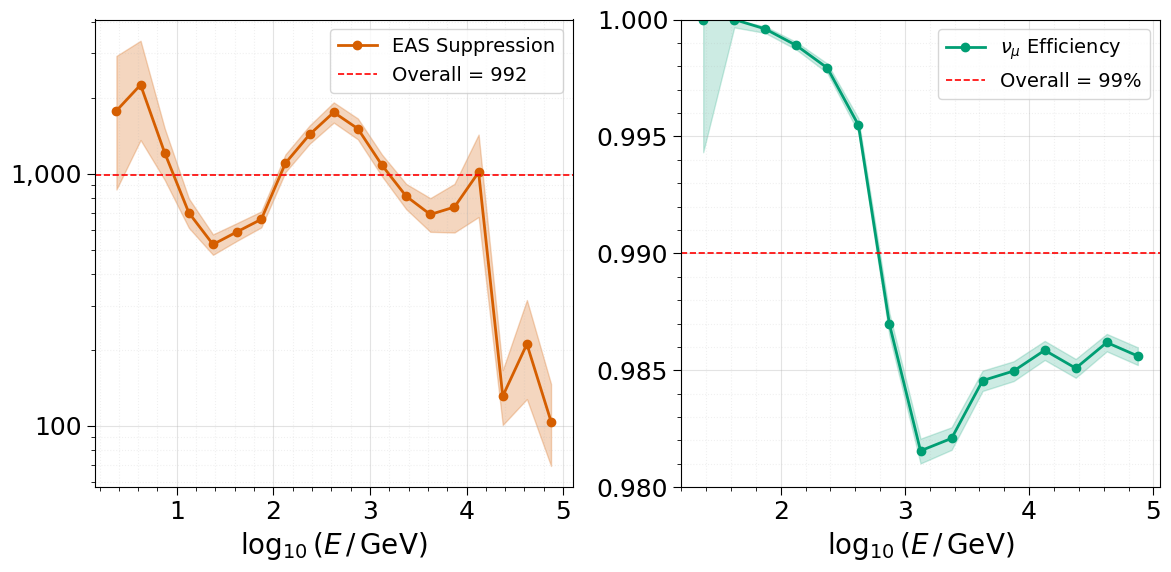

In [ ]:
from scipy.stats import beta as beta_dist

# ── Suppression & Efficiency vs Energy at ref_thr ──
LOG10_E_BINS = np.linspace(0, 5, 21)
bin_centers  = 0.5 * (LOG10_E_BINS[:-1] + LOG10_E_BINS[1:])
ENERGY   = df_mc['energy'].values
LOG10_E  = np.log10(np.maximum(ENERGY, 1e-9))
PASSES   = SCORES >= ref_thr


def _beta_iqr(n_pass, n_tot):
    n_fail = n_tot - n_pass
    a = n_pass + 0.5
    b = np.maximum(n_fail + 0.5, 0.5)
    return beta_dist.ppf(0.25, a, b), beta_dist.ppf(0.75, a, b)


def energy_binned_suppression(mask, bins):
    E = LOG10_E[mask]
    P = PASSES[mask]
    n_tot, _  = np.histogram(E, bins=bins)
    n_pass, _ = np.histogram(E[P], bins=bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        supp         = np.where(n_pass > 0, n_tot / n_pass, np.nan)
        acc_q25, acc_q75 = _beta_iqr(np.maximum(n_pass, 1), np.maximum(n_tot, 1))
        raw_lo       = 1.0 / np.maximum(acc_q75, 1e-9)
        raw_hi       = 1.0 / np.maximum(acc_q25, 1e-9)
        supp_lo      = np.where(n_pass > 0, np.minimum(raw_lo, supp), np.nan)
        supp_hi      = np.where(n_pass > 0, np.maximum(raw_hi, supp), np.nan)
    return supp, supp_lo, supp_hi, n_tot


def energy_binned_efficiency(mask, bins):
    E = LOG10_E[mask]
    P = PASSES[mask]
    n_tot, _  = np.histogram(E, bins=bins)
    n_pass, _ = np.histogram(E[P], bins=bins)
    with np.errstate(divide="ignore", invalid="ignore"):
        eff     = np.where(n_tot > 0, n_pass / np.maximum(n_tot, 1), np.nan)
        q25, q75 = _beta_iqr(np.maximum(n_pass, 0), np.maximum(n_tot, 1))
        eff_lo  = np.where(n_tot > 0, np.minimum(q25, eff), np.nan)
        eff_hi  = np.where(n_tot > 0, np.maximum(q75, eff), np.nan)
    return eff, eff_lo, eff_hi, n_tot


mu_q    = IS_MU     & quality
nue2_q  = pos_nue2  & quality
nuatm_q = pos_nuatm & quality

supp,     supp_lo,  supp_hi,  n_mu    = energy_binned_suppression(mu_q,    LOG10_E_BINS)
nu_q = (pos_nue2 | pos_nuatm) & quality
eff_nu, elo_nu, ehi_nu, n_nu = energy_binned_efficiency(nu_q, LOG10_E_BINS)

# ── Shared x limits ──
valid_mu    = np.isfinite(supp)     & (n_mu    >= 5)
valid_nu  = np.isfinite(eff_nu) & (n_nu >= 5)
any_valid = valid_mu | valid_nu
x_lim = (bin_centers[any_valid].min() - 0.1, bin_centers[any_valid].max() + 0.1)

with plt.rc_context(RC_PARAMS):
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 6))

    # ── Left: EAS suppression ──
    ax1.fill_between(bin_centers[valid_mu], supp_lo[valid_mu], supp_hi[valid_mu], alpha=0.25, color="#D55E00")
    ax1.plot(bin_centers[valid_mu], supp[valid_mu], color="#D55E00", lw=2,
            marker="o", ms=6, label="EAS Suppression")
    ax1.axhline(ref_supp, color="red", ls="--", lw=1.2, label=f"Overall = {ref_supp:.0f}")
    ax1.set_yscale("log")
    #ax1.set_xlim(x_lim)
    ax1.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{GeV})$")
    #ax1.set_ylabel("EAS Suppression")
    #ax1.set_title(f"EAS Suppression vs Energy\n@ thr = {ref_thr:.3f}  [{CUT_LABEL}]", fontsize=10)
    ax1.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, _: f"{x:,.0f}"))
    ax1.yaxis.set_minor_formatter(ticker.NullFormatter())
    ax1.legend()
    ax1.minorticks_on()
    ax1.grid(True, which="major", alpha=0.35)
    ax1.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax1.tick_params(which="major", length=6)
    ax1.tick_params(which="minor", length=3)

    # ── Right: ν efficiency ──
    ax2.fill_between(bin_centers[valid_nu],
                    np.clip(elo_nu[valid_nu], 0, 1),
                    np.clip(ehi_nu[valid_nu], 0, 1),
                    alpha=0.2, color="#009E73")
    ax2.plot(bin_centers[valid_nu], eff_nu[valid_nu], color="#009E73", lw=2,
            marker="o", ms=6, label=r"$\nu_\mu$ Efficiency")

    ax2.axhline(REF_TPR_TARGET, color="red", ls="--", lw=1.2,
                label=fr"Overall = {int(REF_TPR_TARGET*100)}%")
    #ax2.set_xlim(x_lim)
    ax2.set_xlabel(r"$\log_{10}(E\,/\,\mathrm{GeV})$")
    #ax2.set_ylabel(r"$\nu$ Efficiency")
    #ax2.set_title(f"ν Efficiency vs Energy\n@ thr = {ref_thr:.3f}  [{CUT_LABEL}]", fontsize=10)
    ax2.set_ylim(0.98, 1.0)
    ax2.xaxis.set_major_locator(ticker.MultipleLocator(1))
    ax2.yaxis.set_major_locator(ticker.MultipleLocator(0.005))
    ax2.legend()
    ax2.minorticks_on()
    ax2.grid(True, which="major", alpha=0.35)
    ax2.grid(True, which="minor", alpha=0.18, linestyle=":")
    ax2.tick_params(which="major", length=6)
    ax2.tick_params(which="minor", length=3)

    fig.tight_layout()
    save_figure(fig, f"DAPrefilterSuppEffVsEnergy_{REF_H}_{REF_S}.png")
    plt.show()


In [ ]:
df_mc

In [ ]:
mu_energy = df_mc[df_mc[]]